# Plane-wave Beamforming (pytorch)

In this notebook, we locate primary microseisms recorded on the Gräfenberg array. The notebook follows three steps:

1. Data: Retrieve necessary waveforms and metadata
2. Grid: Define slowness grid
3. Beamforming: compute cross-correlation beamformer output within a frequency band

For more background information, see the README.

## 1. Data

### 1.1 Download data and metadata

In [89]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from obspy.clients.fdsn import Client
from obspy.signal.util import util_geo_km
from obspy import UTCDateTime

# BGR Hannover hosts the Gräfenberg array data,
# as per http://fdsn.org/networks/detail/GR/
client = Client("BGR")

# Download one month of Gräfenberg data at 1Hz sampling rate (enough for our purposes)
starttime = UTCDateTime("2019-01-01T00:00:00.000Z")
endtime = UTCDateTime("2019-02-01T00:00:00.000Z")
st = client.get_waveforms(
    network="GR",
    station="GR*",
    location="*",
    channel="LHZ",
    starttime=starttime,
    endtime=endtime,
)

# ensure all traces have exactly same length and start exactly at specified time
# for this demonstration, potential gaps and missing data are fine
st.merge(fill_value=0)
st.trim(starttime=starttime, endtime=endtime, pad=True, fill_value=0)

# Get metadata for all stations to extract locations and remove instrument response
inventory = client.get_stations(
    network="GR",
    station="GR*",
    location="*",
    channel="LHZ",
    level="response",
    starttime=starttime,
    endtime=endtime,
)

### 1.2 Extract geometry

Text(0.5, 1.0, 'Gräfenberg array')

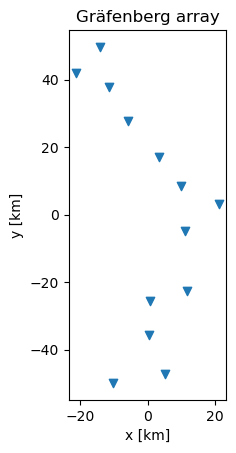

In [90]:
# extract coordinates from metadata
# save station names to ensure correct order of coordinates and seismograms
coordinates = []
station_names = []
for network in inventory:
    for station in network:
        coordinates.append(
            [
                station.longitude,
                station.latitude,
            ]
        )
        station_names.append(station.code)
coordinates = torch.tensor(coordinates)

# convert lat/lon coordinates to cartesian coordinates
# allows easier relative travel time computation later
reference_coordinates = coordinates.mean(axis=0)
coordinates_cartesian = torch.tensor(
    [
        util_geo_km(
            orig_lat=reference_coordinates[1],
            orig_lon=reference_coordinates[0],
            lat=lat,
            lon=lon,
        )
        for lon, lat in coordinates
    ]
)

fig, ax = plt.subplots()
ax.scatter(*coordinates_cartesian.T, marker="v")
ax.set_aspect("equal")
ax.set_xlabel("x [km]")
ax.set_ylabel("y [km]")
ax.set_title("Gräfenberg array")

### 1.3 Extract waveforms

In [91]:
# write waveforms into tensor in correct order
# first convert to numpy array, because torch.tensor is slow for list of np.ndarrays
waveforms_orig = torch.tensor(
    np.array([st.select(station=station)[0].data for station in station_names])
)

# create waveforms tensor with overlapping windows
window_length = 2 * 3600  # [sec]
window_overlap = 0.5  # between 0 and 1

# starttimes of beamforming windows
starttimes = torch.arange(
    0,
    (endtime - starttime) - window_length,
    window_length * (1 - window_overlap),
)

sampling_rate = int(st[0].stats.sampling_rate)
expected_window_length = window_length * sampling_rate

waveforms = torch.zeros((len(starttimes), len(coordinates), expected_window_length))
for window_idx, stime in enumerate(starttimes):
    waveforms[window_idx, :, :] = waveforms_orig[
        :,
        int(stime * sampling_rate) : int(stime * sampling_rate)
        + expected_window_length,
    ]

# convert to frequency domain
spectra = torch.fft.fft(waveforms, dim=-1)
freqs = torch.fft.fftfreq(expected_window_length, 1 / sampling_rate)
omega = 2 * torch.pi * freqs

## 2. Grid

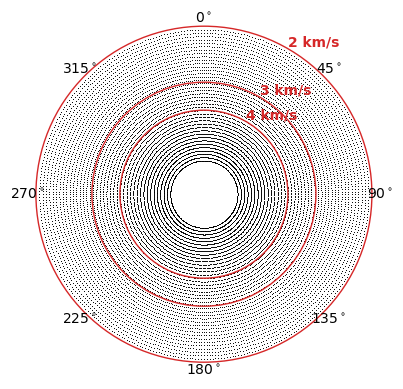

In [92]:
from itertools import product

import pylab as plt
from matplotlib.patches import Circle

# slowness/azimuth grid for plane-wave beamforming
backazimuth_spacing = 1.0
slowness_min = 0.1
slowness_max = 0.5
slowness_spacing = 0.01

azs = torch.arange(0, 2 * torch.pi, backazimuth_spacing * 2 * torch.pi / 360)
slows = torch.arange(slowness_min, slowness_max, slowness_spacing)
slowness_space = torch.tensor(
    [(torch.cos(az) * s, torch.sin(az) * s) for az, s in product(azs, slows)]
)

# plotting
fig, ax = plt.subplots(1)
ax.scatter(*slowness_space.T, c="k", s=0.5, lw=0)
ax.set_aspect("equal")
ax.set_frame_on(False)
ax.set_xticks([])
ax.set_yticks([])

# add and label velocity circles
for v in [2, 3, 4]:
    ax.add_patch(Circle((0, 0), 1 / v, fill=False, color="tab:red"))
    ax.text(
        1 / v * np.cos(2 * np.pi / 6),
        1 / v * np.sin(2 * np.pi / 6),
        f"{v} km/s",
        ha="left",
        va="bottom",
        color="tab:red",
        fontsize=10,
        fontweight="bold",
    )

# add cardinal directions
for az in torch.arange(0, 360, 45):
    ax.text(
        1.05 * slowness_max * np.sin(np.radians(az)),
        1.05 * slowness_max * np.cos(np.radians(az)),
        f"{az}$^\circ$",
        ha="center",
        va="center",
        fontsize=10,
    )

## 3. Beamforming

Here, we compute beampowers using cross-correlation beamforming

$B(\mathbf{r_s}) = \sum_\omega \sum_j \sum_{k\neq j} K_{jk}(\omega) S_{kj}(\mathbf{r_s}, \omega)$,

with $B$ the beampower for potential source location $\mathbf{r_s}$, $j,k$ the sensors indices, $K$ the cross-spectral density matrix of recorded signals, and $S$ the cross-spectral density matrix of Green's functions (or replica vectors). For more details, see the README.

In [98]:
# Frequency band to use for beamform
fmin, fmax = 0.1, 5.0

# theoretical relative plane-wave travel times between all stations
reference_point = torch.mean(coordinates_cartesian, axis=0)
relative_coords = reference_point - coordinates_cartesian
traveltimes_space = torch.einsum("nx, sx -> sn", relative_coords, slowness_space)

# limit to frequency band of interest for
# a) speed-up
# b) focusing on specific frequencies
freq_idx = torch.where((freqs > fmin) & (freqs < fmax))[0]
omega_lim = omega[freq_idx]
spectra_lim = spectra[:, :, freq_idx]

# Green's functions between all stations and all grid points
# within selected frequency band
# G = exp(-iωt)
greens_functions = torch.exp(
    -1j * omega_lim[None, None, :] * traveltimes_space[:, :, None]
)

# force complexdouble type
# fixes type mismatch that arises from 1j -> cfloat, but fft -> cdouble
greens_functions = greens_functions.type(torch.cfloat)

# cross-spectral density matrix of Green's functions
S = greens_functions[:, :, None, :] * greens_functions.conj()[:, None, :, :]

# cross-spectral density matrix of recordings
K = torch.einsum("tjw, tkw -> tjkw", spectra_lim, spectra_lim.conj())
# K = spectra_lim[:, None, :] * spectra_lim.conj()[None, :, :]

# exclude auto-correlations, i.e., do "cross-correlation beamforming"
diag_idxs = torch.arange(K.shape[1])
zero_spectra = torch.zeros(omega_lim.shape, dtype=torch.cfloat)
K[:, diag_idxs, diag_idxs, :] = zero_spectra

# Compute cross-correlation beampower
# using einsum, which automatically identifies ideal path
# this is about 2x faster than numpy einsum from my experience
beampowers = torch.einsum("sjkw, tkjw -> ts", S, K).real

IndexError: index 3531142 is out of bounds for dimension 0 with size 14400

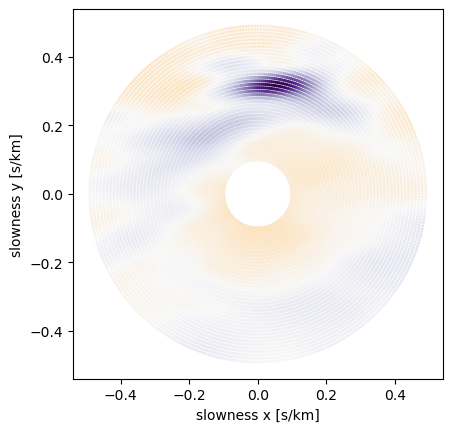

In [99]:
fig, ax = plt.subplots(1)
beampower_average = beampowers.mean(dim=0)
bp_for_plot = beampower_average.reshape(len(azs), len(slows))
bp_for_plot /= bp_for_plot.max()
sct = ax.scatter(
    slowness_space[:, 0],
    slowness_space[:, 1],
    c=bp_for_plot,
    s=5,
    vmin=-1,
    vmax=1,
    cmap="PuOr",
    ec="None",
    lw=0,
)

ax.set_aspect("equal")

ax.set_xlabel("slowness x [s/km]")
ax.set_ylabel("slowness y [s/km]")

# pick maximum and label
max_slowness = slowness_space[torch.argmax(beampowers)]
# convert to backazimuth and slowness
max_b = torch.atan2(max_slowness[1], max_slowness[0])
max_s = torch.linalg.norm(max_slowness)
ax.scatter(*max_slowness, c="r", s=5, label="maximum")
ax.text(
    *max_slowness,
    f"{max_b:.1f}$^\circ$, {max_s:.2f}s/km",
    fontsize=8,
    ha="left",
    va="bottom",
)

# colorbar
x0, y0, w, h = ax.get_position().bounds
cax = fig.add_axes([x0 + w + 0.01, y0, 0.02, h])
plt.colorbar(sct, cax=cax, label="normalised beampower")